In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec


import os

import seaborn as sns



In [2]:
colors_list = [ '#263238','#2E5BFF', "#D4AF37", '#D81B60', '#558B2F', '#7B1FA2', '#E65100']  # ,   '#94A3B8' 
unique_categories = ['common',  'SADE unique', 'CR unique', 'TSS unique',  'SADE+CR, not TSS', 'SADE+TSS, not CR', 'CR+TSS, not SADE', ]


cat_colors_map = dict(zip(unique_categories, colors_list))                  
cat_labels_map = dict(zip(unique_categories, unique_categories))


jitter_width = 0.25
position_offset = [0] + [-jitter_width] * 3 + [jitter_width] * 3  # Adjust offsets for each category
cat_position_map = dict(zip(unique_categories, position_offset))

In [3]:
def add_jittered_points(ax, data_group, position, jitter_width=0.3, s = 15, alpha=0.5, color='orange', marker='*', edgecolors='none', lw=1):
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=alpha, s=s, zorder=1, marker=marker, lw=lw, edgecolors=edgecolors) # s controls point size


# Load data

In [4]:
# Load barcode dataframe 
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
Union_cell_info_file = os.path.join(Union_cell_subdir, 'Union_cell_3set_all_info.tsv')
union_cell_info = pd.read_csv(Union_cell_info_file, sep='\t', index_col=0)
union_cell_info.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris,_3set_identified_by_atac
atac_bc,,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,NO,common
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,NO,common


In [5]:
# Load fragments file
frag_file = os.path.join(entropy_dir, 'fragments.tsv')
frag = pd.read_csv(frag_file, sep='\t', index_col=3, header=None)
frag.index.name ='atac_BC'
frag.columns = ['chrom', 'start', 'end', 'support']
frag['atac_bc'] = frag.index.map(lambda x: x.split('-1')[0])
frag['frag_length'] = frag['end'] - frag['start']



In [6]:
# Load FRIP score corresponding to each peak-set 
frag_in_Raw_peak_file = os.path.join(Union_cell_subdir, 'Rawpeaks', 'frag_overlap/frag_in_peaks.tsv')

frag_in_Entropy_peak_file = os.path.join(Union_cell_subdir, 'Entropy_cells_peaks', 'frag_overlap/frag_in_peaks.tsv')
frag_in_TSSe_peak_file = os.path.join(Union_cell_subdir, 'TSS_cells_peaks', 'frag_overlap/frag_in_peaks.tsv')
frag_in_CR_peak_file = os.path.join(Union_cell_subdir, 'FRIP_cells_peaks', 'frag_overlap/frag_in_peaks.tsv')
frag_in_Common_peak_file = os.path.join(Union_cell_subdir, 'Commoncells_peaks', 'frag_overlap/frag_in_peaks.tsv')

frag_in_raw_peaks = pd.read_csv(frag_in_Raw_peak_file, sep='\t', index_col=3, header=None)
frag_in_entropy_peaks = pd.read_csv(frag_in_Entropy_peak_file, sep='\t', index_col=3, header=None)
frag_in_tsse_peaks = pd.read_csv(frag_in_TSSe_peak_file, sep='\t', index_col=3, header=None)
frag_in_cr_peaks = pd.read_csv(frag_in_CR_peak_file, sep='\t', index_col=3, header=None)
frag_in_common_peaks = pd.read_csv(frag_in_Common_peak_file, sep='\t', index_col=3, header=None)

for df in [frag_in_raw_peaks, frag_in_entropy_peaks, frag_in_tsse_peaks, frag_in_cr_peaks, frag_in_common_peaks]:
    df.index.name ='atac_BC'
    df.columns = ['chrom', 'start', 'end', 'support']
    df['atac_bc'] = df.index.map(lambda x: x.split('-1')[0])
    df['frag_length'] = df['end'] - df['start']

In [7]:
# Fragments in blacklist regions
columns =['chrom', 'start', 'end', 'support'] 
frag_in_blacklist_file = os.path.join(Union_cell_subdir, 'frag_in_blacklist.tsv')
frag_in_blacklist = pd.read_csv(frag_in_blacklist_file, sep='\t', index_col=3, header=None)
frag_in_blacklist['atac_bc'] = frag_in_blacklist.index.map(lambda x: x.split('-1')[0])

# FRIP on each peak-set comparision among 3 cell-calling approaches

## FRIP distribution

In [8]:
total_frag_per_bc = union_cell_info.copy()

for col, df in zip(['Nfrag_in_raw_peaks', 'Nfrag_in_entropy_peaks', 'Nfrag_in_tsse_peaks', 'Nfrag_in_cr_peaks', 'Nfrag_in_common_peaks'], 
               [frag_in_raw_peaks, frag_in_entropy_peaks, frag_in_tsse_peaks, frag_in_cr_peaks, frag_in_common_peaks]):
    total_frag_per_bc[col] = total_frag_per_bc.index.map(df.groupby('atac_bc').size())
    frip_col_name = 'FRIP_' + col.split('_in_')[1]
    total_frag_per_bc[frip_col_name] = total_frag_per_bc[col] / total_frag_per_bc['total_fragments'] 

total_frag_per_bc['Nfrag_in_blacklist'] = total_frag_per_bc.index.map(frag_in_blacklist.groupby('atac_bc').size())
total_frag_per_bc['Nfrag_in_blacklist'] = total_frag_per_bc['Nfrag_in_blacklist'].fillna(0)
total_frag_per_bc['blacklist_ratio'] = total_frag_per_bc['Nfrag_in_blacklist'] / total_frag_per_bc['total_fragments'] 

In [9]:
total_frag_per_bc.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,...,Nfrag_in_entropy_peaks,FRIP_entropy_peaks,Nfrag_in_tsse_peaks,FRIP_tsse_peaks,Nfrag_in_cr_peaks,FRIP_cr_peaks,Nfrag_in_common_peaks,FRIP_common_peaks,Nfrag_in_blacklist,blacklist_ratio
atac_bc,,,,,,,,,,,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,...,1919,0.795605,1933,0.801410,1785,0.740050,1932,0.800995,19.0,0.007877
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,...,1847,0.204540,1877,0.207863,1635,0.181063,1878,0.207973,90.0,0.009967


In [10]:
frip_info_file = os.path.join(Union_cell_subdir, 'frip_cells_info.tsv')
total_frag_per_bc.to_csv(frip_info_file, sep='\t')

## Vis

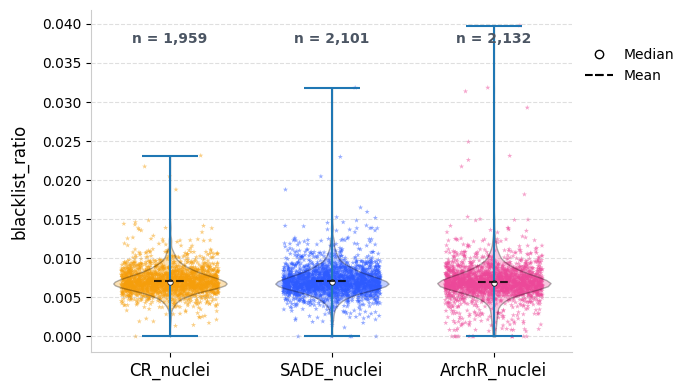

----- 	   CR 	 entropy_only 	 ArchR 
mean 	 ['0.0071', '0.0071', '0.0070']
median 	 ['0.0070', '0.0069', '0.0069']


In [11]:

np.random.seed(999) # For reproducibility of jitter
fig, ax = plt.subplots(ncols=1, figsize=(7, 4))

width = 0.9
set_colors_map = ['#F59E0B', '#2E5BFF', '#EC4899', ]
set_cols = ['atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS']
set_labels = ['CR_nuclei', 'SADE_nuclei', 'ArchR_nuclei']

frip_values = [ total_frag_per_bc['blacklist_ratio'].loc[total_frag_per_bc[cat] == True] for 
               cat in set_cols ]
x_positions = range(len(frip_values))

for i, group_data in enumerate(frip_values):
    add_jittered_points(ax, group_data, x_positions[i], color=set_colors_map[i])

v1 = ax.violinplot( frip_values, 
              positions=x_positions, widths=0.7, 
              showmedians=False, showmeans=False)

total_counts = [ frip.shape[0] for frip in frip_values ]
for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1] * 0.9, f'n = {count:,}', ha='center', 
            fontsize=10, color='#4B5563', fontweight='bold')

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(set_colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.3)
    body.set_zorder(2)

# 4. Add "Inner Boxplot" elements for a premium look
for i, group_data in enumerate(frip_values):
    quartile1, median, quartile3 = np.percentile(group_data, [25, 50, 75])
    mean = np.mean(group_data)
    # Draw a thin line for the mean
    ax.hlines(mean, x_positions[i] - 0.1, x_positions[i] + 0.1, color='black', linestyle='--', lw=1.5, alpha=0.8, zorder=4)
    ax.scatter(x_positions[i], median, color='white', s=15, zorder=3, edgecolor='black', lw=0.5)

ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_xticks(x_positions)
ax.set_xticklabels(set_labels, fontsize=12, fontweight='medium')
ax.set_ylabel('blacklist_ratio', fontsize=12, labelpad=10)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Median', markerfacecolor='white', markeredgecolor='black', markersize=6),
    Line2D([0], [0], marker='_', color='black', label='Mean', markersize=6, markeredgewidth=1.5, linestyle='--'),
]
ax.legend(handles=legend_elements, loc='lower left', frameon=False, fontsize=10, bbox_to_anchor=(1, 0.75))

plt.tight_layout()
plt.show()

mean_frip_values = [f'{np.mean(a):.4f}' for a in frip_values]
median_frip_values = [f'{np.median(a):.4f}' for a in frip_values]
print('----- \t   CR \t entropy_only \t ArchR ')
print(f'mean \t {mean_frip_values}')
print(f'median \t {median_frip_values}')

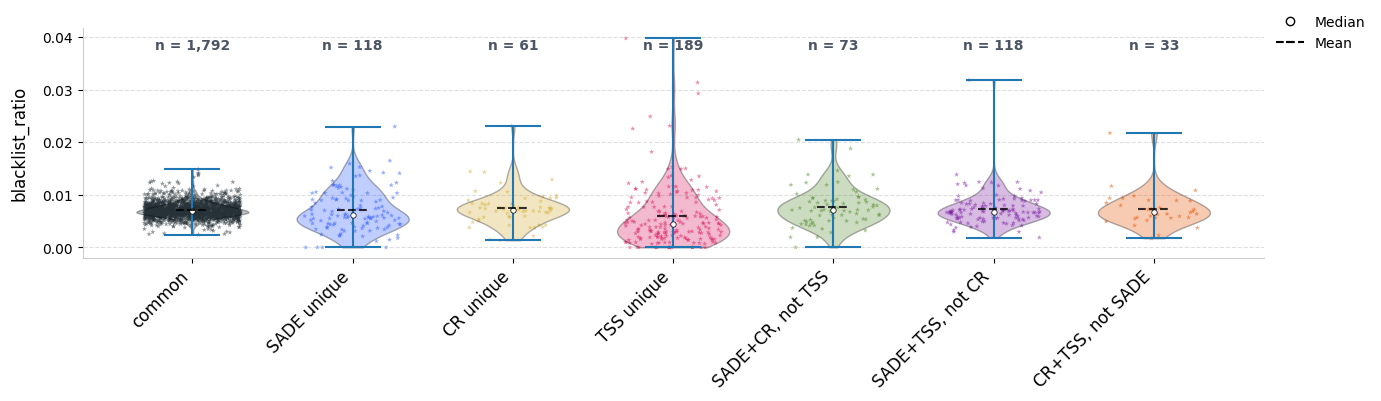

-----   common]  [SADE unique]  [CR unique]  [TSS unique]  [SADE+CR, not TSS]  [SADE+TSS, not CR]  [CR+TSS, not SADE  
mean 	 ['0.007  ', '0.007  ', '0.007  ', '0.006  ', '0.008  ', '0.007  ', '0.007  ']
median 	 ['0.007  ', '0.006  ', '0.007  ', '0.004  ', '0.007  ', '0.007  ', '0.007  ']


In [12]:
np.random.seed(999) # For reproducibility of jitter
fig, ax = plt.subplots(ncols=1, figsize=(14, 4))

width = 0.9


frip_values = [ total_frag_per_bc['blacklist_ratio'].loc[total_frag_per_bc['_3set_identified_by_atac'] == cat] for 
               cat in unique_categories ]
x_positions = range(len(frip_values))

for i, cat in enumerate(unique_categories):
    group_data = frip_values[i]
    add_jittered_points(ax, group_data, x_positions[i], color=cat_colors_map[cat])
v1 = ax.violinplot( frip_values, 
              positions=x_positions, widths=0.7, 
              showmedians=False, showmeans=False)

total_counts = [ frip.shape[0] for frip in frip_values ]
for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1] * 0.9, f'n = {count:,}', ha='center', 
            fontsize=10, color='#4B5563', fontweight='bold')

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(cat_colors_map[unique_categories[i]])
    body.set_edgecolor('black')
    body.set_alpha(0.3)
    body.set_zorder(2)

# 4. Add "Inner Boxplot" elements for a premium look
for i, group_data in enumerate(frip_values):
    quartile1, median, quartile3 = np.percentile(group_data, [25, 50, 75])
    mean = np.mean(group_data)
    # Draw a thin line for the mean
    ax.hlines(mean, x_positions[i] - 0.1, x_positions[i] + 0.1, color='black', linestyle='--', lw=1.5, alpha=0.8, zorder=4)
    ax.scatter(x_positions[i], median, color='white', s=15, zorder=3, edgecolor='black', lw=0.5)

ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_xticks(x_positions)
ax.set_xticklabels(cat_labels_map, fontsize=12, fontweight='medium', rotation=45, ha='right')
ax.set_ylabel('blacklist_ratio', fontsize=12, labelpad=10)
# ax.set_ylim(0, 105)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Median', markerfacecolor='white', markeredgecolor='black', markersize=6),
    Line2D([0], [0], marker='_', color='black', label='Mean', markersize=6, markeredgewidth=1.5, linestyle='--'),
]
ax.legend(handles=legend_elements, loc='lower left', frameon=False, fontsize=10, bbox_to_anchor=(1, 0.85))

plt.tight_layout()
plt.show()


mean_frip_values = [f'{np.mean(a):.3f}  ' for a in frip_values]
median_frip_values = [f'{np.median(a):.3f}  ' for a in frip_values]
print('-----   ' + ']  ['.join(unique_categories) + '  ')
print(f'mean \t {mean_frip_values}')
print(f'median \t {median_frip_values}')

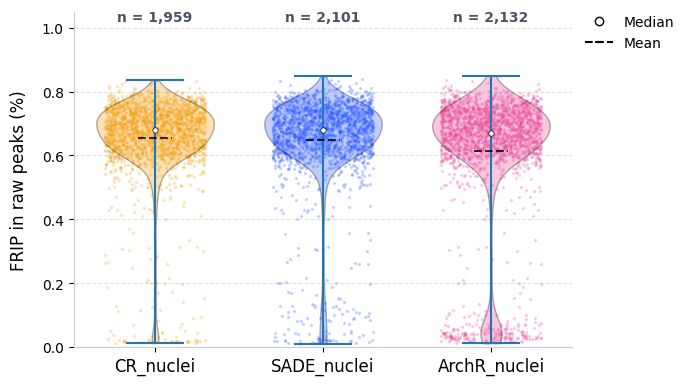

----- 	   CR 	 entropy_only 	 ArchR 
mean 	 ['0.65', '0.65', '0.61']
median 	 ['0.68', '0.68', '0.67']


In [13]:
def add_jittered_points(ax, data_group, position, jitter_width=0.3, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.2, s=2, zorder=1) # s controls point size



np.random.seed(999) # For reproducibility of jitter
fig, ax = plt.subplots(ncols=1, figsize=(7, 4))

width = 0.9
set_colors_map = ['#F59E0B', '#2E5BFF', '#EC4899', ]
set_cols = ['atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS']
set_labels = ['CR_nuclei', 'SADE_nuclei', 'ArchR_nuclei']

frip_values = [ total_frag_per_bc['FRIP_raw_peaks'].loc[total_frag_per_bc[cat] == True] for 
               cat in set_cols ]
x_positions = range(len(frip_values))

for i, group_data in enumerate(frip_values):
    add_jittered_points(ax, group_data, x_positions[i], color=set_colors_map[i])

v1 = ax.violinplot( frip_values, 
              positions=x_positions, widths=0.7, 
              showmedians=False, showmeans=False)

total_counts = [ frip.shape[0] for frip in frip_values ]
for i, count in enumerate(total_counts):
    ax.text(x_positions[i], 1.02, f'n = {count:,}', ha='center', 
            fontsize=10, color='#4B5563', fontweight='bold')

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(set_colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.3)
    body.set_zorder(2)

# 4. Add "Inner Boxplot" elements for a premium look
for i, group_data in enumerate(frip_values):
    quartile1, median, quartile3 = np.percentile(group_data, [25, 50, 75])
    mean = np.mean(group_data)
    # Draw a thin line for the mean
    ax.hlines(mean, x_positions[i] - 0.1, x_positions[i] + 0.1, color='black', linestyle='--', lw=1.5, alpha=0.8, zorder=4)
    ax.scatter(x_positions[i], median, color='white', s=15, zorder=3, edgecolor='black', lw=0.5)

ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_xticks(x_positions)
ax.set_xticklabels(set_labels, fontsize=12, fontweight='medium')
ax.set_ylabel('FRIP in raw peaks (%)', fontsize=12, labelpad=10)
ax.set_ylim(0, 1.05)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Median', markerfacecolor='white', markeredgecolor='black', markersize=6),
    Line2D([0], [0], marker='_', color='black', label='Mean', markersize=6, markeredgewidth=1.5, linestyle='--'),
]
ax.legend(handles=legend_elements, loc='lower left', frameon=False, fontsize=10, bbox_to_anchor=(1, 0.85))

plt.tight_layout()
plt.show()

mean_frip_values = [f'{np.mean(a):.2f}' for a in frip_values]
median_frip_values = [f'{np.median(a):.2f}' for a in frip_values]
print('----- \t   CR \t entropy_only \t ArchR ')
print(f'mean \t {mean_frip_values}')
print(f'median \t {median_frip_values}')


## comparing FRIP in each peak-set

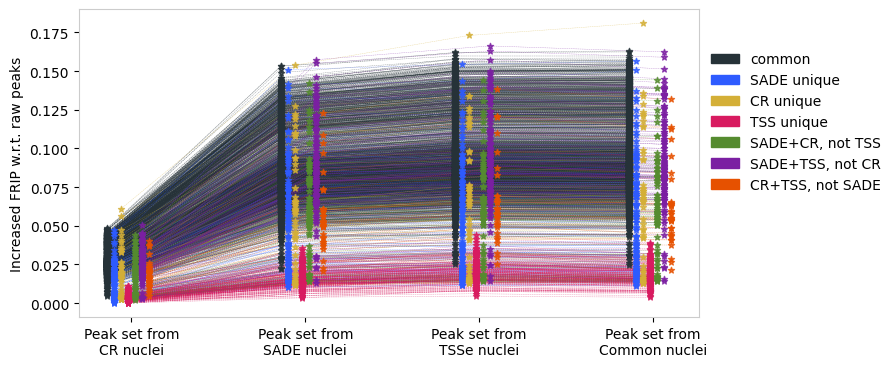

In [18]:
fig, ax = plt.subplots(ncols=1, figsize=(8, 4))

position_offset = 0.04 * (np.arange( len(unique_categories)) -  len(unique_categories)/2)  

frip_col_names = [ 'cr_peaks',  'entropy_peaks', 'tsse_peaks', 'common_peaks']
frip_col_name = [f'FRIP_' + col for col in frip_col_names]
frip_col_labels = ['Peak set from\nCR nuclei', 'Peak set from\nSADE nuclei', 'Peak set from\nTSSe nuclei', 'Peak set from\nCommon nuclei']

for i, cat in enumerate(unique_categories):
    
    datapoints_index = total_frag_per_bc['_3set_identified_by_atac'] == cat
    color = cat_colors_map[cat]
    frip_diff = total_frag_per_bc.loc[datapoints_index, frip_col_name] - total_frag_per_bc.loc[datapoints_index, 'FRIP_raw_peaks'].values[:, None]
    # Plot the lines with x-position offset to avoid overlap
    _ = ax.plot(position_offset[i] + np.arange(len(frip_diff.T)), frip_diff.T, alpha=0.5, color=color,  markersize=4, linestyle='--', linewidth=0.3)
    # Enhance visibility of individual points by adding jittered scatter on top of the lines
    N_datapoints = frip_diff.shape[0]
    for j, col in enumerate(frip_col_name):
        _ = ax.scatter(np.repeat(position_offset[i] + j, N_datapoints), frip_diff.iloc[:, j], alpha=0.8, color=color, marker='*', s=20, zorder=3)

handles = [mpatches.Patch(color=cat_colors_map[cat], label=cat) for cat in unique_categories]
ax.legend(handles=handles, frameon=False, title='', bbox_to_anchor=(1., 0.9), loc='upper left')
ax.set_xticks(range(len(frip_col_name)))
ax.set_xticklabels(frip_col_labels, rotation=0, ha='center')
ax.set_ylabel('Increased FRIP w.r.t. raw peaks')


for edge in ['top', 'right', 'left', 'bottom']:
    ax.spines[edge].set_color('#cccccc')


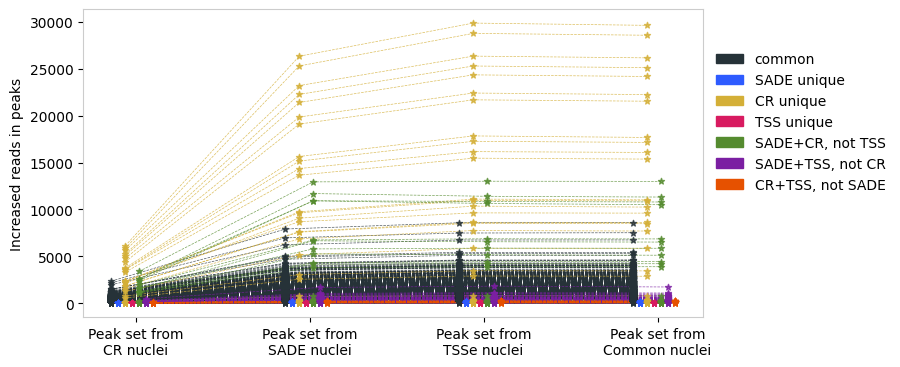

In [17]:
fig, ax = plt.subplots(ncols=1, figsize=(8, 4))


frip_col_names = [ 'cr_peaks',  'entropy_peaks', 'tsse_peaks', 'common_peaks']
frip_col_name = [f'Nfrag_in_{col}' for col in frip_col_names]
frip_col_labels = ['Peak set from\nCR nuclei', 'Peak set from\nSADE nuclei', 'Peak set from\nTSSe nuclei', 'Peak set from\nCommon nuclei']


position_offset = 0.04 * (np.arange( len(unique_categories)) -  len(unique_categories)/2)  
for i, cat in enumerate(unique_categories):

    datapoints_index = total_frag_per_bc['_3set_identified_by_atac'] == cat
    color = cat_colors_map[cat]
    frip_diff = total_frag_per_bc.loc[datapoints_index, frip_col_name] - total_frag_per_bc.loc[datapoints_index, 'Nfrag_in_raw_peaks'].values[:, None]
    # Plot the lines with x-position offset to avoid overlap
    _ = ax.plot(position_offset[i] + np.arange(len(frip_diff.T)), frip_diff.T, alpha=0.8, color=color,  markersize=4, linestyle='--', linewidth=0.5)
    # Enhance visibility of individual points by adding jittered scatter on top of the lines
    N_datapoints = frip_diff.shape[0]
    for j, col in enumerate(frip_col_name):
        _ = ax.scatter(np.repeat(position_offset[i] + j, N_datapoints), frip_diff.iloc[:, j], alpha=0.8, color=color, marker='*', s=20, zorder=3)

handles = [mpatches.Patch(color=cat_colors_map[cat], label=cat) for cat in unique_categories]
ax.legend(handles=handles, frameon=False, title='', bbox_to_anchor=(1.0, 0.9), loc='upper left')
ax.set_xticks(range(len(frip_col_name)))
ax.set_xticklabels(frip_col_labels, rotation=0, ha='center')
ax.set_ylabel('Increased reads in peaks')


for edge in ['top', 'right', 'left', 'bottom']:
    ax.spines[edge].set_color('#cccccc')

/tmp/ipykernel_2102874/3524875056.py:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[i].scatter(total_frag_per_bc[f'Nfrag_in_{x}'],
/tmp/ipykernel_2102874/3524875056.py:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[i].scatter(total_frag_per_bc[f'Nfrag_in_{x}'],
/tmp/ipykernel_2102874/3524875056.py:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[i].scatter(total_frag_per_bc[f'Nfrag_in_{x}'],


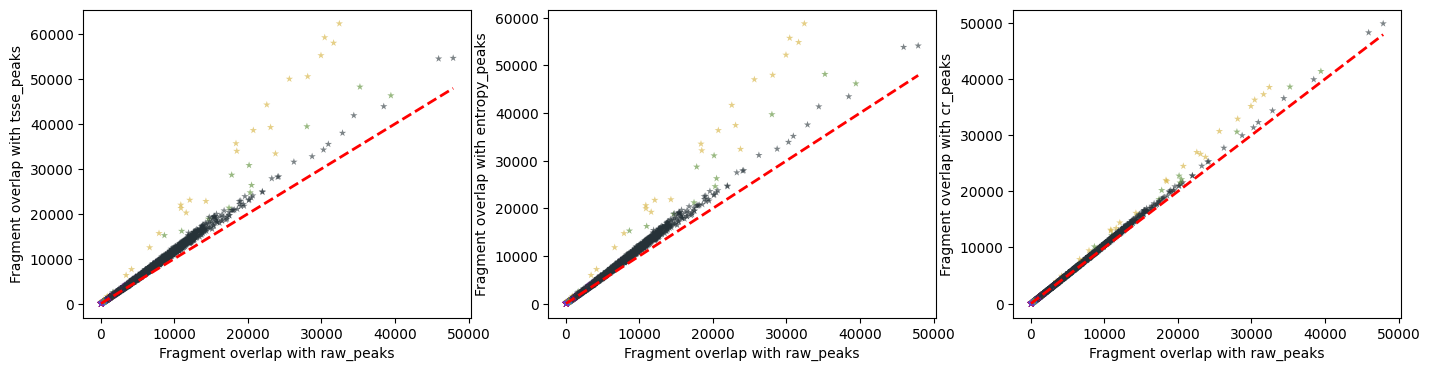

In [ ]:
fig, ax = plt.subplots(ncols=3, figsize=(17, 4))


for i, y in enumerate(['tsse_peaks', 'entropy_peaks', 'cr_peaks']):
    x = 'raw_peaks'
    
    ax[i].scatter(total_frag_per_bc[f'Nfrag_in_{x}'], 
               total_frag_per_bc[f'Nfrag_in_{y}'], 
               c =total_frag_per_bc['_3set_identified_by_atac'].map(cat_colors_map), cmap='Set1', alpha=0.6, s=30, edgecolors='none', marker='*')
    
    ax[i].set_xlabel(f'Fragment overlap with {x}')
    ax[i].set_ylabel(f'Fragment overlap with {y}')
    
    vmax = total_frag_per_bc[f'Nfrag_in_{x}'].max()
    
    ax[i].plot([0, vmax], [0, vmax],  color='red', linestyle='--', linewidth=2)

/tmp/ipykernel_2102874/3386250698.py:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[i].scatter(total_frag_per_bc[f'FRIP_{x}'],
/tmp/ipykernel_2102874/3386250698.py:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[i].scatter(total_frag_per_bc[f'FRIP_{x}'],
/tmp/ipykernel_2102874/3386250698.py:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[i].scatter(total_frag_per_bc[f'FRIP_{x}'],


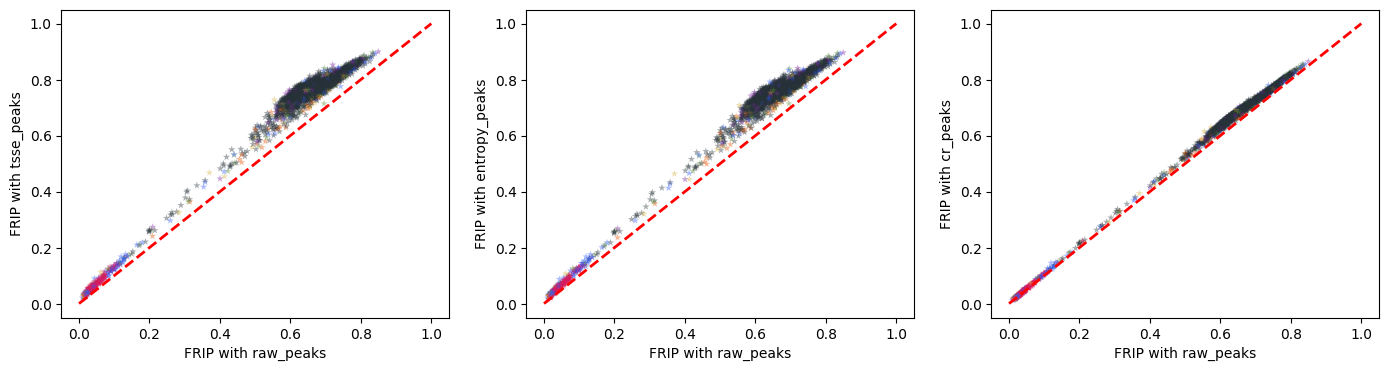

In [20]:
fig, ax = plt.subplots(ncols=3, figsize=(17, 4))


for i, y in enumerate(['tsse_peaks', 'entropy_peaks', 'cr_peaks']):
    x = 'raw_peaks'
    
    ax[i].scatter(total_frag_per_bc[f'FRIP_{x}'], 
               total_frag_per_bc[f'FRIP_{y}'], 
               c =total_frag_per_bc['_3set_identified_by_atac'].map(cat_colors_map), cmap='Set1', alpha=0.4, s=30, marker='*', edgecolor='none')
    
    ax[i].set_xlabel(f'FRIP with {x}')
    ax[i].set_ylabel(f'FRIP with {y}')

    ax[i].plot([0, 1], [0, 1],  color='red', linestyle='--', linewidth=2)

## 